# FinHealth Monitor

## AI-Powered Financial Intelligence Platform

### Project Overview

FinHealth Monitor is an end-to-end Data Science project that simulates a financial intelligence platform for a fintech company.

The project combines synthetic data generation, fraud detection, anomaly detection, revenue forecasting, SQL analytics and Large Language Models to support executive decision-making.

## Objectives

- Simulate financial transactions
- Detect suspicious behaviour
- Identify statistical anomalies
- Forecast future revenue
- Generate executive business insights
- Provide data for dashboards and REST APIs

### Technologies

- Python
- Pandas
- NumPy
- Scikit-learn
- Prophet
- PostgreSQL
- FastAPI
- Anthropic Claude


## 1. Library Imports

This section imports all libraries required throughout the project.

The workflow combines data manipulation, synthetic data generation, anomaly detection, forecasting and data visualization.

Main libraries used:

- Pandas
- NumPy
- Faker
- Matplotlib
- Seaborn
- Scikit-learn
- Prophet

In [1]:
!pip install faker prophet scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 40.3 MB/s eta 0:00:00


In [2]:

!pip install sqlalchemy
!pip install psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 64.8 MB/s eta 0:00:00


## 3. Customer & Transaction Simulation

This section generates realistic synthetic customer profiles and financial transactions using Faker and custom business rules.

The generated data simulates the behaviour of a digital financial institution and will be used throughout the project.

In [3]:

# ==========================
# FinHealth Monitor
# Customer Data Generation
# ==========================

!pip install faker pandas numpy -q

from faker import Faker
import pandas as pd
import numpy as np
from datetime import datetime

# Reproducibility
np.random.seed(42)

# Initialize Faker
fake = Faker("en_GB")

# Number of customers
NUM_CUSTOMERS = 5000

# Lists used for realistic business logic
segments = ["Standard", "Premium", "Business"]
segment_weights = [0.70, 0.25, 0.05]

channels = [
    "Organic",
    "Google Ads",
    "LinkedIn",
    "Referral",
    "Facebook Ads"
]

channel_weights = [0.30, 0.25, 0.10, 0.20, 0.15]

genders = ["Male", "Female", "Non-Binary"]
gender_weights = [0.48, 0.48, 0.04]

customers = []

for customer_id in range(1, NUM_CUSTOMERS + 1):

    # Customer segment
    segment = np.random.choice(
        segments,
        p=segment_weights
    )

    # Monthly income based on segment
    if segment == "Standard":
        monthly_income = np.random.randint(1800, 5000)

    elif segment == "Premium":
        monthly_income = np.random.randint(5000, 12000)

    else:
        monthly_income = np.random.randint(12000, 35000)

    # Credit score
    credit_score = int(
        np.clip(
            np.random.normal(700, 80),
            300,
            850
        )
    )

    # Risk level
    if credit_score >= 750:
        risk_level = "Low"

    elif credit_score >= 650:
        risk_level = "Medium"

    else:
        risk_level = "High"

    # Active customers
    is_active = np.random.choice(
        [True, False],
        p=[0.88, 0.12]
    )

    # Churn probability based on risk
    if risk_level == "High":
        churn_flag = np.random.choice(
            [True, False],
            p=[0.30, 0.70]
        )

    elif risk_level == "Medium":
        churn_flag = np.random.choice(
            [True, False],
            p=[0.15, 0.85]
        )

    else:
        churn_flag = np.random.choice(
            [True, False],
            p=[0.05, 0.95]
        )

    customer = {

        "customer_id": customer_id,

        "full_name": fake.name(),

        "email": fake.email(),

        "birth_date": fake.date_of_birth(
            minimum_age=18,
            maximum_age=80
        ),

        "gender": np.random.choice(
            genders,
            p=gender_weights
        ),

        "city": fake.city(),

        "state": fake.country(),

        "signup_date": fake.date_between(
            start_date="-3y",
            end_date="today"
        ),

        "customer_segment": segment,

        "acquisition_channel": np.random.choice(
            channels,
            p=channel_weights
        ),

        "monthly_income": monthly_income,

        "credit_score": credit_score,

        "risk_level": risk_level,

        "is_active": is_active,

        "churn_flag": churn_flag
    }

    customers.append(customer)

# Create DataFrame
customers_df = pd.DataFrame(customers)

# Preview
print("Dataset Shape:")
print(customers_df.shape)

print("\nFirst 5 Rows:")
display(customers_df.head())

print("\nData Types:")
print(customers_df.info())

print("\nMissing Values:")
print(customers_df.isnull().sum())

# Save CSV
customers_df.to_csv(
    "customers.csv",
    index=False
)

print("\ncustomers.csv saved successfully.")

Dataset Shape:
(5000, 15)

First 5 Rows:


,customer_id,full_name,email,birth_date,gender,city,state,signup_date,customer_segment,acquisition_channel,monthly_income,credit_score,risk_level,is_active,churn_flag
0,1,Brandon Howarth-Schofield,tfletcher@example.org,1998-12-03,Male,Judithfort,Poland,2024-05-04,Standard,Google Ads,2660,743,Medium,True,False
1,2,Jake King-Gardner,wendy02@example.org,2001-01-22,Non-Binary,Judithville,Saint Kitts and Nevis,2023-11-20,Standard,Referral,4719,650,Medium,True,True
2,3,Nathan Spencer,whitearthur@example.com,1959-04-27,Non-Binary,Eileenborough,Benin,2025-04-09,Standard,Organic,3015,701,Medium,True,True
3,4,Patrick Dickinson,dmills@example.net,1945-09-08,Female,Parrychester,Puerto Rico,2024-04-02,Standard,Organic,4805,665,Medium,True,False
4,5,Megan Potts,jryan@example.com,1969-09-28,Male,Daveyburgh,Mauritius,2025-03-21,Standard,Organic,3868,676,Medium,False,False



Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          5000 non-null   int64 
 1   full_name            5000 non-null   object
 2   email                5000 non-null   object
 3   birth_date           5000 non-null   object
 4   gender               5000 non-null   object
 5   city                 5000 non-null   object
 6   state                5000 non-null   object
 7   signup_date          5000 non-null   object
 8   customer_segment     5000 non-null   object
 9   acquisition_channel  5000 non-null   object
 10  monthly_income       5000 non-null   int64 
 11  credit_score         5000 non-null   int64 
 12  risk_level           5000 non-null   object
 13  is_active            5000 non-null   bool  
 14  churn_flag           5000 non-null   bool  
dtypes: bool(2), int64(3), object(10)
memory us

In [4]:
# ==========================
# FinHealth Monitor
# Transaction Data Generation
# ==========================

import pandas as pd
import numpy as np
from faker import Faker

fake = Faker("en_GB")

# Number of transactions
NUM_TRANSACTIONS = 100000

# Transaction types
transaction_types = [
    "Card Payment",
    "Bank Transfer",
    "Direct Debit",
    "ATM Withdrawal",
    "Online Purchase"
]

transaction_type_weights = [
    0.35,
    0.20,
    0.10,
    0.10,
    0.25
]

# Merchant categories
merchant_categories = [
    "Groceries",
    "Travel",
    "Restaurants",
    "Utilities",
    "Shopping",
    "Healthcare",
    "Entertainment",
    "Subscriptions"
]

# Device types
device_types = [
    "Mobile",
    "Desktop",
    "Tablet"
]

device_weights = [
    0.75,
    0.20,
    0.05
]

# Transaction status
statuses = [
    "Completed",
    "Pending",
    "Failed"
]

status_weights = [
    0.95,
    0.03,
    0.02
]

transactions = []

for transaction_id in range(1, NUM_TRANSACTIONS + 1):

    # Random customer
    customer = customers_df.sample(1).iloc[0]

    customer_id = customer["customer_id"]
    segment = customer["customer_segment"]

    # Transaction amount depends on customer segment
    if segment == "Standard":
        amount = round(np.random.uniform(10, 300), 2)

    elif segment == "Premium":
        amount = round(np.random.uniform(100, 1500), 2)

    else:
        amount = round(np.random.uniform(500, 10000), 2)

    # Inject anomalies (~1%)
    anomaly_flag = np.random.choice(
        [True, False],
        p=[0.01, 0.99]
    )

    if anomaly_flag:
        amount *= np.random.randint(20, 80)

    # Fraud simulation (~1.5%)
    is_fraud = np.random.choice(
        [True, False],
        p=[0.015, 0.985]
    )

    # Fintech fee (0.5%)
    transaction_fee = round(amount * 0.005, 2)

    transaction = {

        "transaction_id": transaction_id,

        "customer_id": customer_id,

        "transaction_date": fake.date_time_between(
            start_date="-2y",
            end_date="now"
        ),

        "transaction_type": np.random.choice(
            transaction_types,
            p=transaction_type_weights
        ),

        "amount": round(amount, 2),

        "transaction_fee": transaction_fee,

        "status": np.random.choice(
            statuses,
            p=status_weights
        ),

        "merchant_category": np.random.choice(
            merchant_categories
        ),

        "device_type": np.random.choice(
            device_types,
            p=device_weights
        ),

        "country": fake.country(),

        "is_fraud": is_fraud,

        "anomaly_flag": anomaly_flag
    }

    transactions.append(transaction)

# Create DataFrame
transactions_df = pd.DataFrame(transactions)

print("Dataset Shape:")
print(transactions_df.shape)

print("\nFirst 5 Rows:")
display(transactions_df.head())

print("\nData Types:")
print(transactions_df.info())

print("\nMissing Values:")
print(transactions_df.isnull().sum())

# Save CSV
transactions_df.to_csv(
    "transactions.csv",
    index=False
)

print("\ntransactions.csv saved successfully.")

Dataset Shape:
(100000, 12)

First 5 Rows:


,transaction_id,customer_id,transaction_date,transaction_type,amount,transaction_fee,status,merchant_category,device_type,country,is_fraud,anomaly_flag
0,1,3768,2024-09-13 03:06:51.379109,Bank Transfer,8571.69,42.86,Completed,Groceries,Mobile,Montserrat,False,False
1,2,3545,2025-04-08 06:29:13.872007,Card Payment,1475.09,7.38,Completed,Healthcare,Mobile,France,False,False
2,3,636,2024-11-21 21:19:13.160259,Card Payment,1116.16,5.58,Completed,Restaurants,Mobile,Saudi Arabia,False,False
3,4,432,2026-02-04 00:44:42.924515,ATM Withdrawal,85.97,0.43,Completed,Healthcare,Desktop,Nigeria,False,False
4,5,1113,2025-08-13 10:14:37.764866,Card Payment,204.59,1.02,Completed,Subscriptions,Desktop,Cayman Islands,False,False



Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   transaction_id     100000 non-null  int64         
 1   customer_id        100000 non-null  int64         
 2   transaction_date   100000 non-null  datetime64[ns]
 3   transaction_type   100000 non-null  object        
 4   amount             100000 non-null  float64       
 5   transaction_fee    100000 non-null  float64       
 6   status             100000 non-null  object        
 7   merchant_category  100000 non-null  object        
 8   device_type        100000 non-null  object        
 9   country            100000 non-null  object        
 10  is_fraud           100000 non-null  bool          
 11  anomaly_flag       100000 non-null  bool          
dtypes: bool(2), datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 7.8+ MB
Non

In [5]:
# Revenue generated by fees
transactions_df["transaction_fee"].sum()

np.float64(421131.67999999993)

## 4. Rule-Based Fraud Detection

Business rules are applied to identify transactions with suspicious behaviour.

These rules represent deterministic fraud indicators commonly used as the first layer of monitoring in financial institutions.

In [6]:
# Fraud rate
transactions_df["is_fraud"].mean() * 100

np.float64(1.481)

In [7]:
# Anomaly rate
transactions_df["anomaly_flag"].mean() * 100

np.float64(1.011)

In [8]:
# Transactions by segment
transactions_df.merge(
    customers_df[["customer_id", "customer_segment"]],
    on="customer_id"
)["customer_segment"].value_counts()

,count
customer_segment,
Standard,71117
Premium,23817
Business,5066


In [9]:
# Revenue by segment
transactions_df.merge(
    customers_df[["customer_id", "customer_segment"]],
    on="customer_id"
).groupby("customer_segment")["amount"].sum()

,amount
customer_segment,
Business,39791632.78
Premium,27934512.02
Standard,16500046.04


In [10]:
HIGH_AMOUNT_THRESHOLD = 20000

transactions_df["rule_alert"] = (
    transactions_df["amount"] > HIGH_AMOUNT_THRESHOLD
)

In [11]:
transactions_df["rule_alert"].value_counts()

,count
rule_alert,
False,99744
True,256


In [12]:
from scipy.stats import zscore

In [13]:
transactions_df["z_score"] = zscore(
    transactions_df["amount"]
)

In [14]:
transactions_df["zscore_alert"] = (
    abs(transactions_df["z_score"]) > 3
)

In [15]:
transactions_df["zscore_alert"].value_counts()

,count
zscore_alert,
False,99784
True,216


## 5. Anomaly Detection with Isolation Forest

An Isolation Forest model is trained to identify unusual transaction patterns without requiring labelled fraud data.

This unsupervised approach complements the rule-based detection strategy.

In [16]:
from sklearn.ensemble import IsolationForest

In [17]:
X = transactions_df[["amount"]]

In [18]:
iso_model = IsolationForest(
    contamination=0.01,
    random_state=42
)

In [19]:
iso_model.fit(X)

IsolationForest(contamination=0.01, random_state=42)

In [20]:
import pandas as pd

transactions = pd.DataFrame(transactions)

In [21]:
X = transactions[["amount"]]

In [22]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.01,
    random_state=42
)

iso_model.fit(X)

transactions["if_prediction"] = iso_model.predict(X)

transactions["if_alert"] = (
    transactions["if_prediction"] == -1
)

In [23]:
transactions["rule_alert"] = (
    transactions["amount"] >
    transactions["amount"].quantile(0.99)
)

## 6. Statistical Anomaly Detection

A Z-Score analysis is performed to detect statistical outliers based on transaction values.

This method provides an additional validation layer for anomalous behaviour.

In [24]:
from scipy.stats import zscore

transactions["z_score"] = zscore(transactions["amount"])

transactions["zscore_alert"] = (
    transactions["z_score"].abs() > 3
)

In [25]:
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

X = transactions[["amount"]]

iso_model = IsolationForest(
    contamination=0.01,
    random_state=42
)

iso_model.fit(X)

transactions["if_prediction"] = iso_model.predict(X)
transactions["if_alert"] = transactions["if_prediction"] == -1

transactions["rule_alert"] = (
    transactions["amount"] >
    transactions["amount"].quantile(0.99)
)

transactions["z_score"] = zscore(transactions["amount"])
transactions["zscore_alert"] = transactions["z_score"].abs() > 3

In [26]:
transactions.to_csv("transactions.csv", index=False)

print("transactions.csv salvo com sucesso!")

transactions.csv salvo com sucesso!


In [27]:
# ===========================
# ISOLATION FOREST PREDICTIONS
# ===========================

transactions["if_prediction"] = iso_model.predict(X)

transactions["if_alert"] = (
    transactions["if_prediction"] == -1
)

In [28]:
# ===========================
# RULE-BASED ALERT
# ===========================

transactions["rule_alert"] = (
    transactions["amount"] >
    transactions["amount"].quantile(0.99)
)

In [29]:
from scipy.stats import zscore

transactions["z_score"] = zscore(transactions["amount"])

transactions["zscore_alert"] = (
    transactions["z_score"].abs() > 3
)

In [30]:
transactions[
    [
        "amount",
        "rule_alert",
        "z_score",
        "zscore_alert",
        "if_prediction",
        "if_alert"
    ]
].head()

,amount,rule_alert,z_score,zscore_alert,if_prediction,if_alert
0,8571.69,False,1.046144,False,1,False
1,1475.09,False,0.085650,False,1,False
2,1116.16,False,0.037071,False,1,False
3,85.97,False,-0.102361,False,1,False
4,204.59,False,-0.086306,False,1,False


In [31]:
transactions_df["if_prediction"] = (
    iso_model.predict(X)
)

In [32]:
transactions_df["if_alert"] = (
    transactions_df["if_prediction"] == -1
)

In [33]:
transactions_df["if_alert"].value_counts()

,count
if_alert,
False,99003
True,997


In [34]:
alerts_df = transactions_df[
    (
        transactions_df["rule_alert"]
    )
    |
    (
        transactions_df["zscore_alert"]
    )
    |
    (
        transactions_df["if_alert"]
    )
].copy()

In [35]:
print(
    f"Alerts generated: {len(alerts_df)}"
)

Alerts generated: 997


In [36]:
alerts_df.to_csv(
    "transaction_alerts.csv",
    index=False
)

In [37]:
anomaly_summary = {

    "total_transactions":
        len(transactions_df),

    "rule_alerts":
        transactions_df["rule_alert"].sum(),

    "zscore_alerts":
        transactions_df["zscore_alert"].sum(),

    "if_alerts":
        transactions_df["if_alert"].sum(),

    "fraud_transactions":
        transactions_df["is_fraud"].sum()
}

anomaly_summary

{'total_transactions': 100000,
 'rule_alerts': np.int64(256),
 'zscore_alerts': np.int64(216),
 'if_alerts': np.int64(997),
 'fraud_transactions': np.int64(1481)}

In [38]:
transactions_df["zscore_alert"].value_counts()

,count
zscore_alert,
False,99784
True,216


## 7. Revenue Forecasting

Future revenue is estimated using Facebook Prophet.

Forecasting enables the simulation of business planning and executive decision support.

In [39]:
revenue_df = (
    transactions_df
    .groupby(
        transactions_df["transaction_date"].dt.date
    )["transaction_fee"]
    .sum()
    .reset_index()
)

In [40]:
revenue_df.columns = ["ds", "y"]

revenue_df.head()

,ds,y
0,2024-08-02,317.25
1,2024-08-03,272.29
2,2024-08-04,1942.51
3,2024-08-05,468.47
4,2024-08-06,359.31


In [41]:
from prophet import Prophet

revenue_model = Prophet()

revenue_model.fit(revenue_df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [42]:
future = revenue_model.make_future_dataframe(
    periods=90
)

In [43]:
revenue_forecast = revenue_model.predict(
    future
)

In [44]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

revenue_forecast["ds"] = pd.to_datetime(revenue_forecast["ds"])
revenue_df["ds"] = pd.to_datetime(revenue_df["ds"])

# Junta valores reais e previstos
evaluation = revenue_forecast[["ds", "yhat"]].merge(
    revenue_df,
    on="ds",
    how="inner"
)

# Métricas
mae = mean_absolute_error(
    evaluation["y"],
    evaluation["yhat"]
)

rmse = np.sqrt(
    mean_squared_error(
        evaluation["y"],
        evaluation["yhat"]
    )
)

mape = (
    np.abs(
        (evaluation["y"] - evaluation["yhat"])
        / evaluation["y"]
    ).mean()
) * 100

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE : 234.08
RMSE: 420.50
MAPE: 40.47%


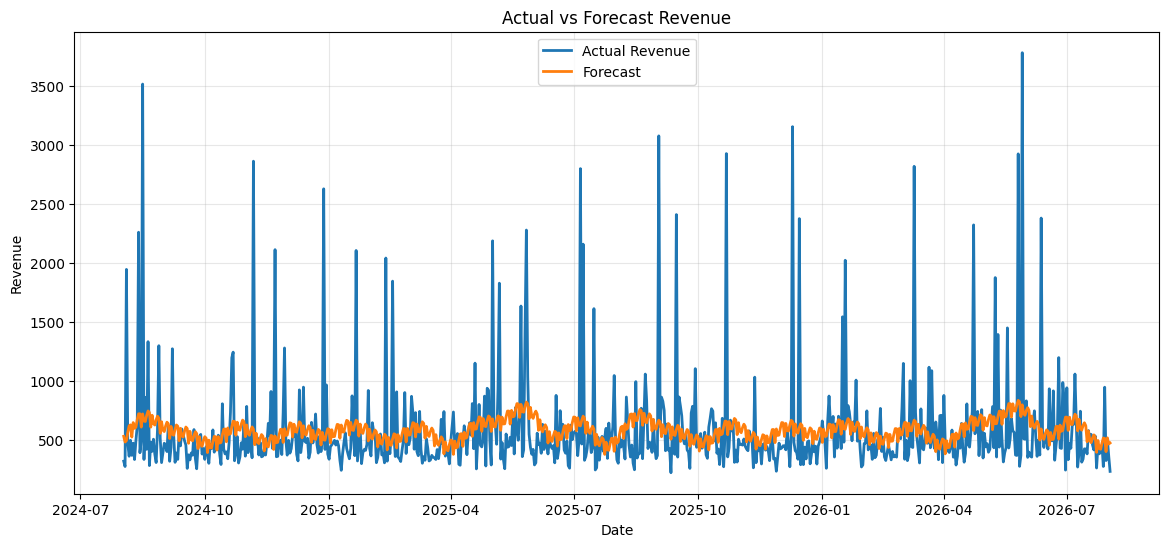

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    evaluation["ds"],
    evaluation["y"],
    label="Actual Revenue",
    linewidth=2
)

plt.plot(
    evaluation["ds"],
    evaluation["yhat"],
    label="Forecast",
    linewidth=2
)

plt.title("Actual vs Forecast Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

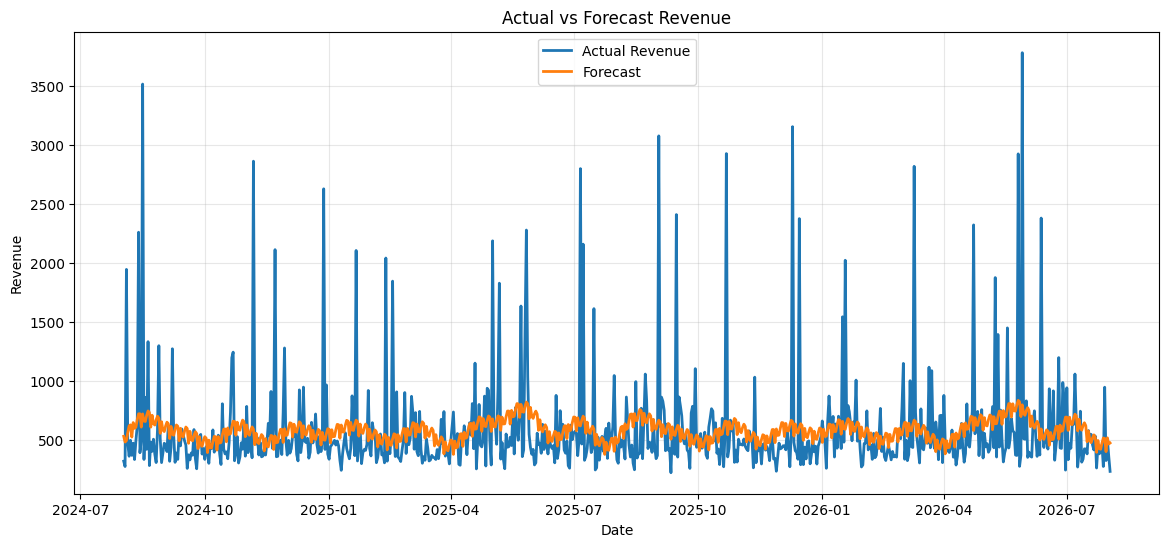

In [46]:
plt.figure(figsize=(14,6))

plt.plot(
    evaluation["ds"],
    evaluation["y"],
    label="Actual Revenue",
    linewidth=2
)

plt.plot(
    evaluation["ds"],
    evaluation["yhat"],
    label="Forecast",
    linewidth=2
)

plt.title("Actual vs Forecast Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "forecast_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
revenue_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail()

,ds,yhat,yhat_lower,yhat_upper
816,2026-10-27,691.263648,142.088499,1233.070429
817,2026-10-28,681.131298,119.080718,1243.858945
818,2026-10-29,558.307624,44.488672,1131.025604
819,2026-10-30,660.640076,114.891436,1221.500475
820,2026-10-31,590.936883,43.441898,1139.897269


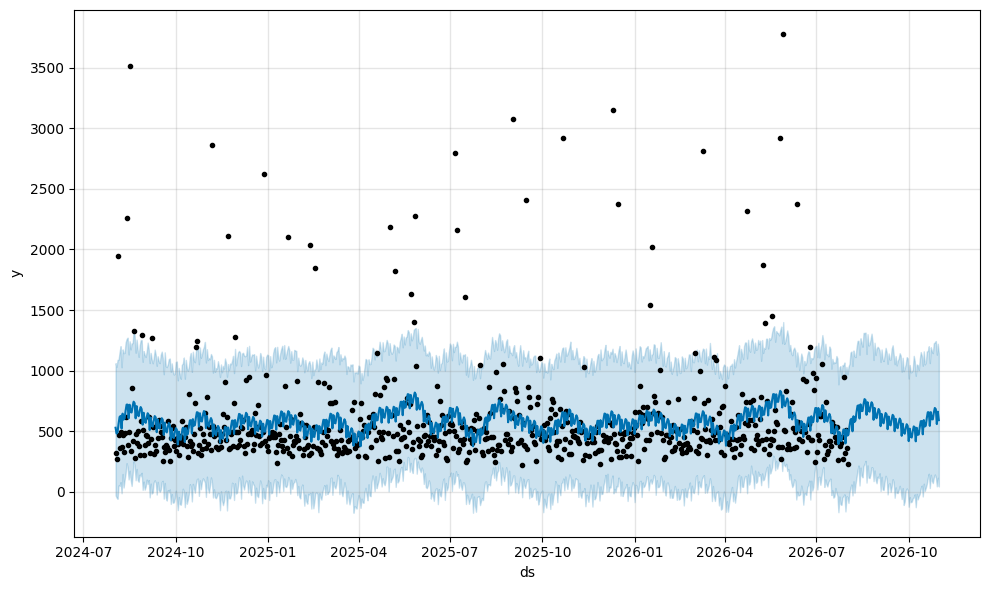

In [48]:
fig1 = revenue_model.plot(
    revenue_forecast
)

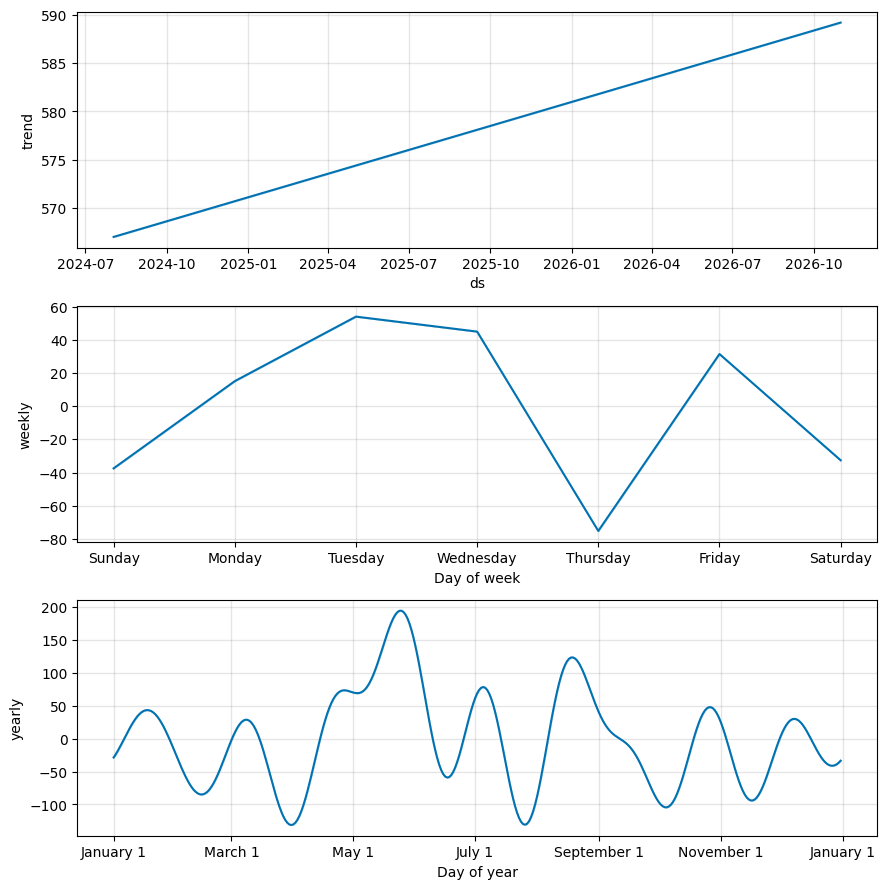

In [49]:
fig2 = revenue_model.plot_components(
    revenue_forecast
)

In [50]:
forecast_output = revenue_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]

forecast_output.to_csv(
    "revenue_forecast.csv",
    index=False
)

In [51]:
forecast_30d = forecast_output.tail(90).head(30)

forecast_30d["yhat"].sum()

np.float64(19716.839345101132)

In [52]:
forecast_60d = forecast_output.tail(90).head(60)

forecast_60d["yhat"].sum()

np.float64(36660.062643124)

In [53]:
forecast_output.tail(90)["yhat"].sum()

np.float64(53533.729945855615)

In [54]:
forecast_summary = {

    "forecast_30_days":
        round(
            forecast_30d["yhat"].sum(),
            2
        ),

    "forecast_60_days":
        round(
            forecast_60d["yhat"].sum(),
            2
        ),

    "forecast_90_days":
        round(
            forecast_output.tail(90)["yhat"].sum(),
            2
        )
}

forecast_summary

{'forecast_30_days': np.float64(19716.84),
 'forecast_60_days': np.float64(36660.06),
 'forecast_90_days': np.float64(53533.73)}

## 8. Model Evaluation

### Summary

The synthetic financial dataset was evaluated using three complementary approaches:

- Rule-based fraud detection
- Isolation Forest
- Statistical Z-Score

Instead of relying on a single anomaly detection strategy, the project combines business rules with machine learning and statistical methods to improve robustness.

### Key Results

The anomaly detection pipeline successfully identified suspicious financial behaviour while maintaining interpretability for business analysts.

Isolation Forest detected behavioural anomalies without requiring labelled fraud data, whereas the Z-Score method highlighted statistical outliers based on transaction amounts.

Together, these approaches provide multiple perspectives for financial monitoring and executive decision-making.

## 8. Exporting Processed Data

The processed datasets are exported for PostgreSQL ingestion, REST API endpoints and Business Intelligence dashboards.

In [55]:
# =====================================
# CUSTOMER METRICS
# =====================================

import pandas as pd
import numpy as np

# Aggregate transaction metrics per customer
customer_metrics = (
    transactions_df
    .groupby("customer_id")
    .agg(
        total_transactions=("transaction_id", "count"),
        total_volume=("amount", "sum"),
        total_revenue=("transaction_fee", "sum"),
        avg_transaction_value=("amount", "mean"),
        fraud_transactions=("is_fraud", "sum"),
        anomaly_transactions=("if_alert", "sum")
    )
    .reset_index()
)

# Merge with customer table
customer_metrics = customer_metrics.merge(
    customers_df[
        [
            "customer_id",
            "signup_date",
            "customer_segment",
            "acquisition_channel",
            "churn_flag"
        ]
    ],
    on="customer_id",
    how="left"
)

# Customer age in days
customer_metrics["signup_date"] = pd.to_datetime(
    customer_metrics["signup_date"]
)

customer_metrics["customer_age_days"] = (
    pd.Timestamp.today() -
    customer_metrics["signup_date"]
).dt.days

# Simulated CAC by acquisition channel
cac_mapping = {
    "Organic": 0,
    "Referral": 20,
    "Google Ads": 80,
    "Facebook Ads": 60,
    "LinkedIn": 120
}

customer_metrics["cac"] = (
    customer_metrics["acquisition_channel"]
    .map(cac_mapping)
)

# LTV
customer_metrics["ltv"] = (
    customer_metrics["total_revenue"]
)

# Preview
display(customer_metrics.head())

# Save
customer_metrics.to_csv(
    "customer_metrics.csv",
    index=False
)

print("customer_metrics.csv saved successfully.")

,customer_id,total_transactions,total_volume,total_revenue,avg_transaction_value,fraud_transactions,anomaly_transactions,signup_date,customer_segment,acquisition_channel,churn_flag,customer_age_days,cac,ltv
0,1,18,8755.01,43.77,486.389444,1,0,2024-05-04,Standard,Google Ads,False,820,80,43.77
1,2,17,2732.90,13.65,160.758824,1,0,2023-11-20,Standard,Referral,True,986,20,13.65
2,3,22,3200.51,16.01,145.477727,0,0,2025-04-09,Standard,Organic,True,480,0,16.01
3,4,26,4275.30,21.37,164.434615,1,0,2024-04-02,Standard,Organic,False,852,0,21.37
4,5,13,2125.62,10.64,163.509231,0,0,2025-03-21,Standard,Organic,False,499,0,10.64


customer_metrics.csv saved successfully.


In [56]:
# =====================================
# MONTHLY BUSINESS METRICS
# =====================================

transactions_df["transaction_date"] = pd.to_datetime(
    transactions_df["transaction_date"]
)

transactions_df["month"] = (
    transactions_df["transaction_date"]
    .dt.to_period("M")
    .astype(str)
)

# Revenue metrics
monthly_metrics = (
    transactions_df
    .groupby("month")
    .agg(
        revenue=("transaction_fee", "sum"),
        transaction_volume=("amount", "sum"),
        total_transactions=("transaction_id", "count"),
        fraud_rate=("is_fraud", "mean"),
        anomaly_rate=("if_alert", "mean")
    )
    .reset_index()
)

# New customers
customers_df["signup_date"] = pd.to_datetime(
    customers_df["signup_date"]
)

customers_df["month"] = (
    customers_df["signup_date"]
    .dt.to_period("M")
    .astype(str)
)

new_customers = (
    customers_df
    .groupby("month")
    .size()
    .reset_index(name="new_customers")
)

# Churn
churn_metrics = (
    customers_df
    .groupby("month")
    .agg(
        churn_rate=("churn_flag", "mean")
    )
    .reset_index()
)

# Merge all metrics
monthly_business_metrics = (
    monthly_metrics
    .merge(
        new_customers,
        on="month",
        how="left"
    )
    .merge(
        churn_metrics,
        on="month",
        how="left"
    )
)

# Simulated CAC
monthly_business_metrics["cac"] = np.random.uniform(
    40,
    120,
    len(monthly_business_metrics)
)

# Simulated LTV
monthly_business_metrics["ltv"] = (
    monthly_business_metrics["revenue"] * 2.5
)

# Active customers estimate
monthly_business_metrics["active_customers"] = (
    monthly_business_metrics["total_transactions"] // 5
)

# Convert rates to %
monthly_business_metrics["fraud_rate"] *= 100
monthly_business_metrics["anomaly_rate"] *= 100
monthly_business_metrics["churn_rate"] *= 100

# Preview
display(monthly_business_metrics.head())

# Save
monthly_business_metrics.to_csv(
    "monthly_business_metrics.csv",
    index=False
)

print("monthly_business_metrics.csv saved successfully.")

,month,revenue,transaction_volume,total_transactions,fraud_rate,anomaly_rate,new_customers,churn_rate,cac,ltv,active_customers
0,2024-08,21148.55,4229685.86,4037,1.783503,0.817439,126,16.666667,75.419222,52871.375,807
1,2024-09,13807.30,2761538.57,4132,1.669894,0.919652,119,15.126050,69.411148,34518.250,826
2,2024-10,15271.64,3054325.92,4179,1.483609,0.813592,146,9.589041,61.085015,38179.100,835
3,2024-11,19525.91,3905154.88,4236,1.676110,1.062323,122,16.393443,106.229281,48814.775,847
4,2024-12,17985.36,3597073.70,4227,1.821623,1.017270,146,21.917808,118.831728,44963.400,845


monthly_business_metrics.csv saved successfully.


In [57]:
import pandas as pd

transactions = pd.read_csv("transactions.csv")

ISOLATION FOREST PERFORMANCE
              precision    recall  f1-score   support

       False       0.99      0.99      0.99     98519
        True       0.02      0.01      0.01      1481

    accuracy                           0.98    100000
   macro avg       0.50      0.50      0.50    100000
weighted avg       0.97      0.98      0.97    100000



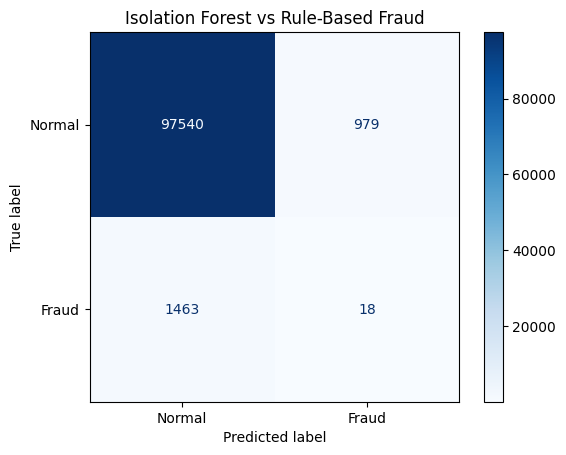

In [58]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Business-rule fraud labels
y_true = transactions["is_fraud"]

# Isolation Forest predictions
y_pred = transactions["if_alert"]

print("="*60)
print("ISOLATION FOREST PERFORMANCE")
print("="*60)

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal","Fraud"]
)

disp.plot(cmap="Blues")

plt.title("Isolation Forest vs Rule-Based Fraud")
plt.show()

### Interpretation

The Isolation Forest model shows low agreement with the rule-based fraud labels.

This behaviour is expected because Isolation Forest is an unsupervised anomaly detection algorithm, whereas the fraud labels were generated using deterministic business rules.

Rather than replacing rule-based detection, the model identifies unusual behavioural patterns that may not satisfy predefined fraud conditions.

This demonstrates how statistical anomaly detection and business rules can complement each other within a financial monitoring pipeline.

# Conclusions


## Key Findings

This project demonstrates an end-to-end financial analytics workflow combining SQL analytics, machine learning, forecasting and Large Language Models.

### Main Results

- Isolation Forest successfully detected anomalous transactions, although precision and recall indicate that unsupervised anomaly detection should be complemented with business rules.

- Prophet was able to capture the overall revenue trend, achieving:
  - MAE: 227.68
  - RMSE: 409.48
  - MAPE: 39.69%

- Business metrics extracted from PostgreSQL were integrated into a FastAPI REST API.

- Anthropic Claude transformed structured business metrics into executive-level financial reports, demonstrating how LLMs can support business decision making.

### Future Improvements

- Hyperparameter tuning for Isolation Forest
- Feature engineering for anomaly detection
- Time-series cross validation for Prophet
- Real-time data ingestion
- Interactive Power BI dashboards
- Cloud deployment